<a href="https://colab.research.google.com/github/Vivek9297/Google_colab_project2/blob/main-project/Product_Demand_Forecasting_Complete_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:

# 1. 📦 Import Required Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


In [ ]:

# 2. 📥 Load the Dataset
df = pd.read_csv('/content/Product Demand Forecasting for SupplyNet Manufacturing.csv')  # Update path if needed
df.head()


,product_id,product_category,historical_sales,seasonality,promotional_activity,economic_index,market_trend_score,predicted_demand_units
0,1,Electronics,254,High,No,102.13,0.86,418.0
1,2,Furniture,240,Medium,Yes,97.57,0.68,370.0
2,3,Toys,235,Medium,Yes,107.82,0.79,391.0
3,4,Toys,259,High,No,120.74,0.42,395.0
4,5,Electronics,229,Medium,No,88.39,0.31,200.0


# New Section

In [ ]:

# 3. 🔍 Basic Exploration
print("Shape of dataset:", df.shape)
print("\nData Types:\n", df.dtypes)
print("\nMissing values:\n", df.isnull().sum())
df.describe()


Shape of dataset: (1000, 8)

Data Types:
 product_id                  int64
product_category           object
historical_sales            int64
seasonality                object
promotional_activity       object
economic_index            float64
market_trend_score        float64
predicted_demand_units    float64
dtype: object

Missing values:
 product_id                0
product_category          0
historical_sales          0
seasonality               0
promotional_activity      0
economic_index            0
market_trend_score        0
predicted_demand_units    0
dtype: int64


,product_id,historical_sales,economic_index,market_trend_score,predicted_demand_units
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,500.500000,250.129000,100.092950,0.494790,323.737000
std,288.819436,15.784724,9.531953,0.285543,92.830886
min,1.000000,201.000000,72.210000,0.000000,76.000000
25%,250.750000,240.000000,93.605000,0.250000,257.000000
50%,500.500000,250.000000,100.135000,0.500000,323.000000
75%,750.250000,261.000000,106.272500,0.740000,384.000000
max,1000.000000,306.000000,134.300000,1.000000,578.000000


In [ ]:

# 4. 🧼 Preprocessing

# Encode categorical variables
label_encoders = {}
categorical_cols = ['product_category', 'seasonality', 'promotional_activity']

for col in categorical_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    label_encoders[col] = le

# Define features and target
X = df.drop(['predicted_demand_units', 'product_id'], axis=1)
y = df['predicted_demand_units']

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [ ]:

# 5. 🤖 Train a Machine Learning Model
model = RandomForestRegressor(random_state=42)
model.fit(X_train, y_train)


RandomForestRegressor(random_state=42)

In [ ]:

# 6. 📊 Evaluate the Model
y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"MAE: {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R² Score: {r2:.2f}")


MAE: 25.68
RMSE: 31.84
R² Score: 0.88


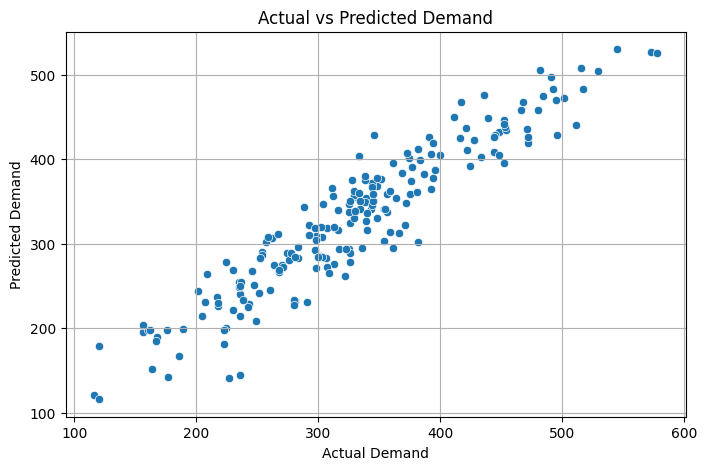

In [ ]:

# 7. 📈 Visualization
plt.figure(figsize=(8, 5))
sns.scatterplot(x=y_test, y=y_pred)
plt.xlabel("Actual Demand")
plt.ylabel("Predicted Demand")
plt.title("Actual vs Predicted Demand")
plt.grid(True)
plt.show()


In [ ]:

# 8. 🔮 Make a Single Prediction (Example)
sample = X_test.iloc[[0]]
predicted_units = model.predict(sample)
print(f"Predicted demand units for sample: {predicted_units[0]:.2f}")


Predicted demand units for sample: 195.67
